In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
import seaborn as sns

In [98]:
df = pd.read_csv("../data/raw/device_telemetry.csv")

EDA


In [99]:
df.shape

(12020, 19)

In [100]:
df.head()

,Device_ID,OS,OS_Version,Manufacturer,Model,Network_Type,Battery_Health,Battery_Temperature,CPU_Usage,Memory_Usage,Storage_Usage,Network_Signal,App_Crash_Count,Reboot_Count,Error_Count,Data_Usage,Days_Since_Last_Update,Last_Checkin_Hours,Failure_Within_7_Days
0,DEV-00001,Android,13.0,Apple,Model_C,4G,83.264927,39.553141,75.992968,53.706658,71.905273,60.879876,2,4,7,3141.410848,3,1.693449,0
1,DEV-00002,iOS,11.0,Dell,Model_D,WiFi,86.814058,33.264014,79.095793,58.568440,60.156997,57.391034,2,2,1,1610.601317,91,29.440840,0
2,DEV-00003,Windows,12.0,Samsung,Model_E,WiFi,88.492257,40.148116,59.021509,56.214448,48.434434,33.145753,0,1,2,2584.005107,86,2.555599,0
3,DEV-00004,Windows,14.0,Honeywell,Model_D,WiFi,73.924453,36.292322,49.454212,53.309786,75.514666,99.447988,3,1,2,1273.264021,47,3.815414,0
4,DEV-00005,Android,13.0,Honeywell,Model_E,WiFi,83.267405,43.406349,20.828683,48.839864,94.537607,67.980414,1,1,3,1724.513745,169,7.058946,0


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12020 entries, 0 to 12019
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Device_ID               12020 non-null  object 
 1   OS                      12020 non-null  object 
 2   OS_Version              11778 non-null  float64
 3   Manufacturer            12020 non-null  object 
 4   Model                   12020 non-null  object 
 5   Network_Type            12020 non-null  object 
 6   Battery_Health          11780 non-null  float64
 7   Battery_Temperature     11780 non-null  float64
 8   CPU_Usage               12020 non-null  float64
 9   Memory_Usage            12020 non-null  float64
 10  Storage_Usage           12020 non-null  float64
 11  Network_Signal          11780 non-null  float64
 12  App_Crash_Count         12020 non-null  int64  
 13  Reboot_Count            12020 non-null  int64  
 14  Error_Count             12020 non-null

In [102]:
df.isnull().sum()

Device_ID                   0
OS                          0
OS_Version                242
Manufacturer                0
Model                       0
Network_Type                0
Battery_Health            240
Battery_Temperature       240
CPU_Usage                   0
Memory_Usage                0
Storage_Usage               0
Network_Signal            240
App_Crash_Count             0
Reboot_Count                0
Error_Count                 0
Data_Usage                  0
Days_Since_Last_Update      0
Last_Checkin_Hours          0
Failure_Within_7_Days       0
dtype: int64

In [103]:
df.isnull().sum().sort_values(ascending=False)

OS_Version                242
Battery_Temperature       240
Battery_Health            240
Network_Signal            240
Device_ID                   0
OS                          0
Model                       0
Network_Type                0
CPU_Usage                   0
Memory_Usage                0
Manufacturer                0
Storage_Usage               0
App_Crash_Count             0
Reboot_Count                0
Error_Count                 0
Data_Usage                  0
Days_Since_Last_Update      0
Last_Checkin_Hours          0
Failure_Within_7_Days       0
dtype: int64

In [105]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})
missing_summary = missing_summary[missing_summary["Missing_Count"]>0]


missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values(
    "Missing_Percentage",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
OS_Version,242,2.01
Battery_Health,240,2.00
Battery_Temperature,240,2.00
Network_Signal,240,2.00


In [106]:
df.duplicated().sum()

np.int64(20)

In [107]:
df["Failure_Within_7_Days"].value_counts(normalize=True) *100

Failure_Within_7_Days
0    71.913478
1    28.086522
Name: proportion, dtype: float64

In [108]:
df.describe()

,OS_Version,Battery_Health,Battery_Temperature,CPU_Usage,Memory_Usage,Storage_Usage,Network_Signal,App_Crash_Count,Reboot_Count,Error_Count,Data_Usage,Days_Since_Last_Update,Last_Checkin_Hours,Failure_Within_7_Days
count,11778.000000,11780.000000,11780.000000,12020.000000,12020.000000,12020.000000,11780.000000,12020.000000,12020.000000,12020.000000,12020.000000,12020.000000,12020.000000,12020.000000
mean,12.741043,77.150513,35.104898,55.003003,60.083058,64.789426,69.709597,2.348170,2.000166,2.992845,2092.877939,90.219301,4.489452,0.280865
std,1.329229,12.593664,5.012814,17.902707,16.056282,17.601793,17.147379,2.618963,1.411446,1.741211,1238.395444,51.812879,4.536856,0.449440
min,10.000000,20.061908,20.000000,5.000000,10.000000,10.000000,5.870057,0.000000,0.000000,0.000000,214.701280,1.000000,0.000138,0.000000
25%,12.000000,69.458555,31.941962,42.759135,49.009937,52.899663,57.906637,1.000000,1.000000,2.000000,1236.101647,45.000000,1.275737,0.000000
50%,13.000000,77.697949,34.914512,55.120780,60.075863,64.686902,69.969441,2.000000,2.000000,3.000000,1800.446890,90.000000,3.104751,0.000000
75%,14.000000,85.848088,38.072295,67.068420,70.951267,77.086303,82.192474,3.000000,3.000000,4.000000,2606.884279,135.000000,6.241118,1.000000
max,15.000000,100.000000,80.575855,100.000000,100.000000,100.000000,100.000000,54.000000,9.000000,11.000000,12628.696455,180.000000,51.026447,1.000000


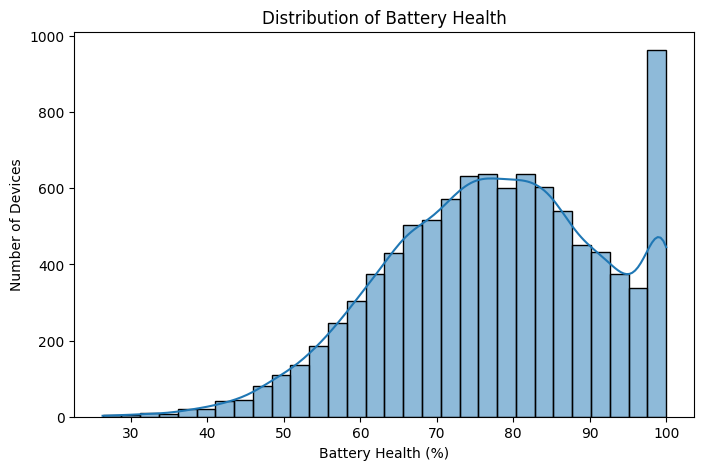

In [67]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Battery_Health",
    bins=30,
    kde=True
)

plt.title("Distribution of Battery Health")
plt.xlabel("Battery Health (%)")
plt.ylabel("Number of Devices")

plt.show()

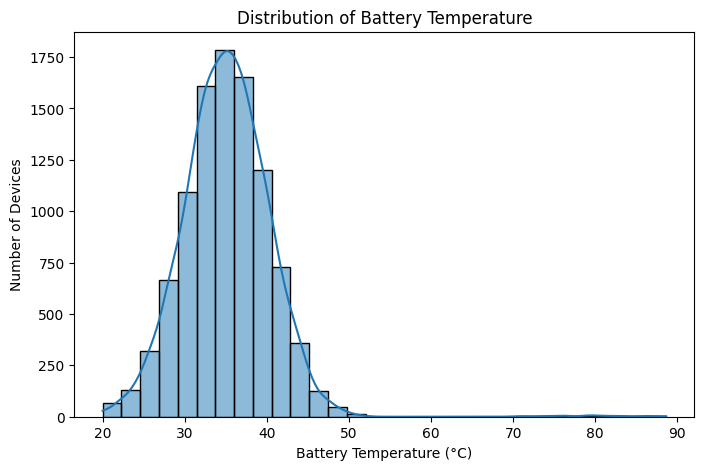

In [68]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Battery_Temperature",
    bins=30,
    kde=True
)

plt.title("Distribution of Battery Temperature")
plt.xlabel("Battery Temperature (°C)")
plt.ylabel("Number of Devices")

plt.show()

In [69]:
df[df["Battery_Temperature"] >= 50]["Battery_Temperature"].sort_values()

5836    50.327629
316     50.662173
4300    50.917170
132     50.965036
941     51.114642
1756    51.903072
7538    52.009378
4576    70.387735
8730    70.583208
5130    71.826248
8705    73.539463
4687    73.548311
1462    74.371793
3401    75.078776
1580    75.915667
5394    76.216100
2663    76.387113
2937    76.464314
4974    78.601869
8931    78.869529
8122    79.057480
5400    79.355058
4981    79.516042
8403    80.012125
2078    80.270097
2967    80.723279
9171    81.384415
782     82.345827
8495    82.397192
9231    83.255774
7627    83.307835
5446    85.335699
9439    85.559064
5953    86.664569
4426    86.760055
2226    88.025397
6485    88.638363
Name: Battery_Temperature, dtype: float64

In [70]:
(df["Battery_Temperature"] >= 70).mean() * 100

np.float64(0.29940119760479045)

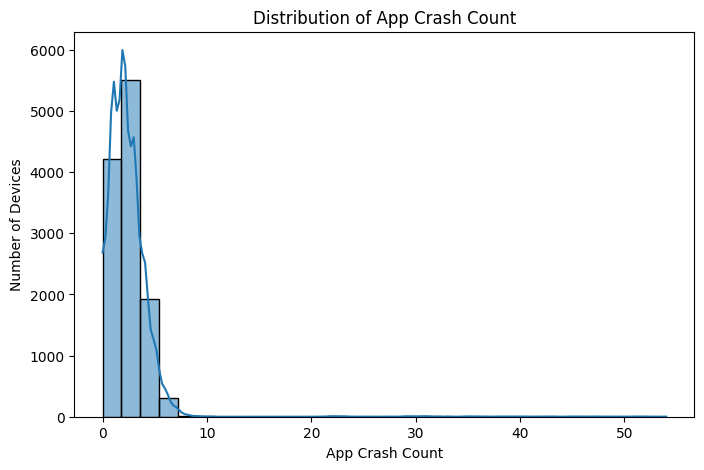

In [109]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="App_Crash_Count",
    bins=30,
    kde=True
)

plt.title("Distribution of App Crash Count")
plt.xlabel("App Crash Count")
plt.ylabel("Number of Devices")

plt.show()

In [110]:
df[df["App_Crash_Count"] >= 9]["App_Crash_Count"] .sort_values()

2770      9
2325      9
4508      9
7688      9
11809     9
6884     10
3051     21
1022     22
5780     22
1042     22
3767     22
1290     23
4352     23
4844     25
9853     27
2408     29
7198     29
4555     29
5560     30
1013     30
3231     31
7099     31
2926     31
2823     31
7730     33
1814     33
4588     35
3656     35
703      35
3944     36
7655     36
3936     38
288      38
8467     39
4913     40
5464     40
9817     41
269      42
3432     43
9797     43
7512     45
5434     45
6667     46
11894    47
6991     47
1103     48
11432    49
959      51
6029     51
6784     52
3314     54
Name: App_Crash_Count, dtype: int64

In [112]:
(df["App_Crash_Count"]>=21).sum()

np.int64(45)

In [74]:
#Investigate if devices with unusually high app crashes actually fail more often?"


In [113]:
df[df["App_Crash_Count"]>=21]["Failure_Within_7_Days"].value_counts()

Failure_Within_7_Days
1    43
0     2
Name: count, dtype: int64

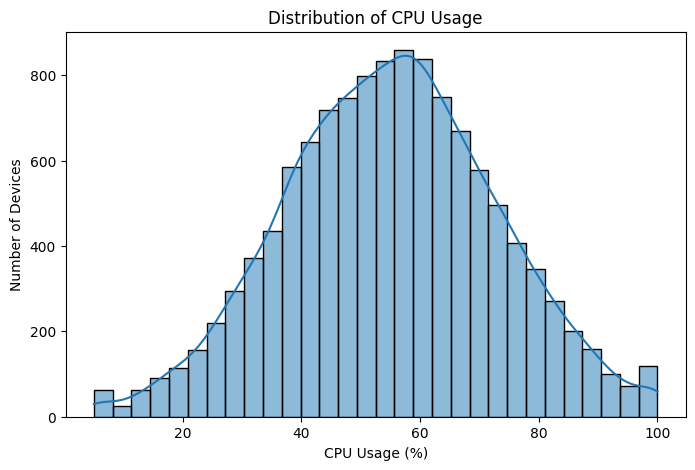

In [114]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="CPU_Usage",
    bins=30,
    kde=True
)

plt.title("Distribution of CPU Usage")
plt.xlabel("CPU Usage (%)")
plt.ylabel("Number of Devices")

plt.show()

In [118]:
df[df["CPU_Usage"]>90]["CPU_Usage"].sort_values()

3224      90.077929
2446      90.102453
2101      90.102864
7364      90.133417
8691      90.150144
            ...    
1876     100.000000
11610    100.000000
11574    100.000000
11686    100.000000
11847    100.000000
Name: CPU_Usage, Length: 306, dtype: float64

In [117]:
df[df["CPU_Usage"] > 90]["Failure_Within_7_Days"].value_counts(
    normalize=True
) * 100

Failure_Within_7_Days
0    50.0
1    50.0
Name: proportion, dtype: float64

In [79]:
#Overall failure rate was 50.14%.
#The high-CPU group has a slightly higher failure rate

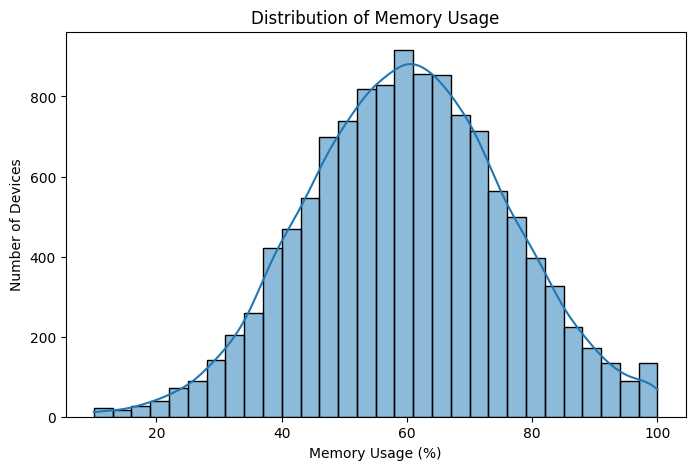

In [119]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Memory_Usage",
    bins=30,
    kde=True
)

plt.title("Distribution of Memory Usage")
plt.xlabel("Memory Usage (%)")
plt.ylabel("Number of Devices")

plt.show()

In [120]:
(df["Memory_Usage"] > 90).mean() * 100

np.float64(3.344425956738769)

In [82]:
#means 4.52% of devices have Memory Usage > 90%.

In [121]:
df[df["Memory_Usage"] > 90]["Failure_Within_7_Days"].value_counts(
    normalize=True
) * 100

Failure_Within_7_Days
1    53.731343
0    46.268657
Name: proportion, dtype: float64

In [84]:
# Devices with memory usage above 90% show a slightly higher observed failure rate
# than the overall population. This suggests a possible association, but it is not sufficient to establish causation.

In [85]:
#1. Understand distribution → 2. Identify unusual values → 3. Quantify → 4. Compare with target → 5. Interpret

In [122]:
df["OS"].value_counts()

OS
Android    6820
Windows    3416
iOS        1784
Name: count, dtype: int64

In [123]:
df.groupby("OS")["Failure_Within_7_Days"].mean() * 100

OS
Android    28.035191
Windows    27.722482
iOS        28.979821
Name: Failure_Within_7_Days, dtype: float64

In [125]:
df["Manufacturer"].value_counts()

Manufacturer
Samsung      2695
Lenovo       2194
Dell         2125
Zebra        1854
Apple        1770
Honeywell    1382
Name: count, dtype: int64

In [126]:
df.groupby("Manufacturer")["Failure_Within_7_Days"].mean() * 100

Manufacturer
Apple        29.717514
Dell         29.364706
Honeywell    25.904486
Lenovo       26.572470
Samsung      28.682746
Zebra        27.615965
Name: Failure_Within_7_Days, dtype: float64

In [127]:
df["OS_Version"].value_counts()

OS_Version
13.0    2949
12.0    2905
14.0    2411
11.0    1838
15.0    1229
10.0     446
Name: count, dtype: int64

In [128]:
df.groupby("OS_Version")["Failure_Within_7_Days"].mean() * 100

OS_Version
10.0    28.699552
11.0    26.985854
12.0    27.297762
13.0    28.246863
14.0    28.204065
15.0    29.373474
Name: Failure_Within_7_Days, dtype: float64

In [92]:
#We've covered enough categorical EDA. The next important step is correlation analysis.

#Correlation helps us understand relationships between numerical features.

In [129]:
correlation = df.select_dtypes(include="number").corr()

correlation

,OS_Version,Battery_Health,Battery_Temperature,CPU_Usage,Memory_Usage,Storage_Usage,Network_Signal,App_Crash_Count,Reboot_Count,Error_Count,Data_Usage,Days_Since_Last_Update,Last_Checkin_Hours,Failure_Within_7_Days
OS_Version,1.000000,-0.006579,-0.003670,0.016963,0.005138,-0.003055,-0.005444,-0.002930,0.009818,-0.004274,0.001699,0.002642,-0.004803,0.012133
Battery_Health,-0.006579,1.000000,0.010120,0.004351,-0.006804,-0.010407,0.012816,0.004921,-0.009833,0.009057,0.008887,-0.002279,0.002189,-0.261533
Battery_Temperature,-0.003670,0.010120,1.000000,0.002259,-0.017761,-0.001386,-0.003864,0.002059,-0.002512,-0.002147,0.000434,-0.013134,0.001565,0.138177
CPU_Usage,0.016963,0.004351,0.002259,1.000000,-0.017480,-0.001790,0.005435,-0.006868,0.001800,-0.004200,-0.013906,-0.000811,0.011865,0.206784
Memory_Usage,0.005138,-0.006804,-0.017761,-0.017480,1.000000,-0.005368,-0.007039,0.004632,0.002977,0.000461,0.007573,-0.001565,-0.014864,0.240584
Storage_Usage,-0.003055,-0.010407,-0.001386,-0.001790,-0.005368,1.000000,0.002930,0.001481,-0.003349,-0.005834,0.003807,-0.007691,-0.003805,0.086711
Network_Signal,-0.005444,0.012816,-0.003864,0.005435,-0.007039,0.002930,1.000000,0.001883,-0.002875,0.013684,-0.010095,-0.002415,0.003755,-0.168441
App_Crash_Count,-0.002930,0.004921,0.002059,-0.006868,0.004632,0.001481,0.001883,1.000000,0.005859,-0.004562,-0.004822,0.002546,-0.004981,0.120418
Reboot_Count,0.009818,-0.009833,-0.002512,0.001800,0.002977,-0.003349,-0.002875,0.005859,1.000000,0.010360,0.022603,0.003835,0.017316,0.051078
Error_Count,-0.004274,0.009057,-0.002147,-0.004200,0.000461,-0.005834,0.013684,-0.004562,0.010360,1.000000,-0.005220,-0.005332,0.019135,0.091663


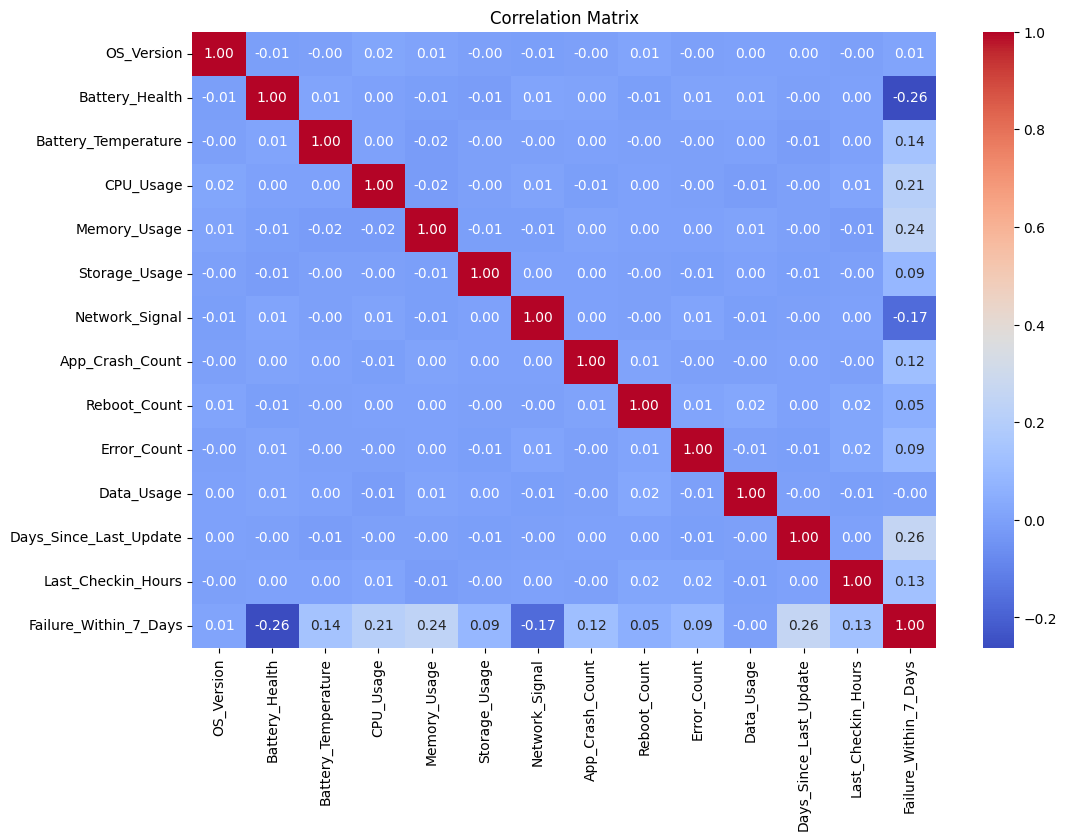

In [130]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [131]:
df.groupby(
    pd.qcut(df["Battery_Health"], 5)
)["Failure_Within_7_Days"].mean() * 100

C:\Users\npb\AppData\Local\Temp\ipykernel_25268\906358081.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


Battery_Health
(20.061, 67.231]    45.882852
(67.231, 74.547]    31.239389
(74.547, 80.731]    26.740238
(80.731, 87.795]    21.561969
(87.795, 100.0]     15.195246
Name: Failure_Within_7_Days, dtype: float64

In [132]:
df.groupby(
    pd.qcut(df["Last_Checkin_Hours"], 5)
)["Failure_Within_7_Days"].mean() * 100

C:\Users\npb\AppData\Local\Temp\ipykernel_25268\3006413835.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


Last_Checkin_Hours
(-0.000862, 0.984]    22.545757
(0.984, 2.288]        24.625624
(2.288, 4.111]        26.497504
(4.111, 7.2]          29.367720
(7.2, 51.026]         37.396007
Name: Failure_Within_7_Days, dtype: float64

In [133]:
df.groupby(
    pd.qcut(df["Error_Count"], 5,duplicates="drop")
)["Failure_Within_7_Days"].mean() * 100

C:\Users\npb\AppData\Local\Temp\ipykernel_25268\1402280712.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


Error_Count
(-0.001, 1.0]    22.186235
(1.0, 2.0]       25.733892
(2.0, 3.0]       29.241071
(3.0, 4.0]       29.239184
(4.0, 11.0]      34.964093
Name: Failure_Within_7_Days, dtype: float64

In [134]:
(df["Battery_Temperature"] >= 60).sum()

np.int64(44)

In [135]:
(df["App_Crash_Count"] >= 20).sum()

np.int64(45)

In [136]:
(df["Last_Checkin_Hours"] > 20).sum()

np.int64(152)

In [143]:
df["Battery_Health_Group"] = pd.qcut(
    df["Battery_Health"],
    3,
    labels=["Low", "Medium", "High"]
)

df["Checkin_Group"] = pd.qcut(
    df["Last_Checkin_Hours"],
    3,
    labels=["Recent", "Moderate", "Long"]
)

pd.crosstab(
    df["Battery_Health_Group"],
    df["Checkin_Group"],
    values=df["Failure_Within_7_Days"],
    aggfunc="mean"
) * 100

Checkin_Group,Recent,Moderate,Long
Battery_Health_Group,,,
Low,35.106383,38.880368,47.895945
Medium,21.362229,23.769871,33.739528
High,13.769752,16.963594,21.652640


In [144]:
df["CPU_Group"] = pd.qcut(
    df["CPU_Usage"],
    3,
    labels=["Low", "Medium", "High"]
)

df["Memory_Group"] = pd.qcut(
    df["Memory_Usage"],
    3,
    labels=["Low", "Medium", "High"]
)

pd.crosstab(
    df["CPU_Group"],
    df["Memory_Group"],
    values=df["Failure_Within_7_Days"],
    aggfunc="mean"
) * 100

Memory_Group,Low,Medium,High
CPU_Group,,,
Low,9.330324,16.207710,28.073916
Medium,15.412979,25.000000,41.551459
High,24.432678,38.284066,54.699538


In [145]:
print((df["Battery_Temperature"] >= 60).sum())
print((df["App_Crash_Count"] >= 20).sum())
print((df["Last_Checkin_Hours"] > 20).sum())

44
45
152


In [ ]:
#EDA Analysis

In [ ]:
# Check for data leakage

In [147]:
#Preprocessing
#Don't preprocess the entire dataset before splitting.

In [149]:
X = df.drop(columns=["Failure_Within_7_Days"])
y = df["Failure_Within_7_Days"]

In [150]:
X = X.drop(columns=["Device_ID"])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y #preserves target distribution
)

In [152]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (9616, 21)
X_test : (2404, 21)
y_train: (9616,)
y_test : (2404,)


In [ ]:
X_train.dtypes #don't blindly use dtype to decide whether something is categorical or numerical.

OS                          object
OS_Version                 float64
Manufacturer                object
Model                       object
Network_Type                object
Battery_Health             float64
Battery_Temperature        float64
CPU_Usage                  float64
Memory_Usage               float64
Storage_Usage              float64
Network_Signal             float64
App_Crash_Count              int64
Reboot_Count                 int64
Error_Count                  int64
Data_Usage                 float64
Days_Since_Last_Update       int64
Last_Checkin_Hours         float64
Battery_Health_Group      category
Checkin_Group             category
CPU_Group                 category
Memory_Group              category
dtype: object

In [154]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

(9616, 21)
(2404, 21)
Failure_Within_7_Days
0    71.911398
1    28.088602
Name: proportion, dtype: float64
Failure_Within_7_Days
0    71.921797
1    28.078203
Name: proportion, dtype: float64


In [155]:
X.columns.tolist()

['OS',
 'OS_Version',
 'Manufacturer',
 'Model',
 'Network_Type',
 'Battery_Health',
 'Battery_Temperature',
 'CPU_Usage',
 'Memory_Usage',
 'Storage_Usage',
 'Network_Signal',
 'App_Crash_Count',
 'Reboot_Count',
 'Error_Count',
 'Data_Usage',
 'Days_Since_Last_Update',
 'Last_Checkin_Hours',
 'Battery_Health_Group',
 'Checkin_Group',
 'CPU_Group',
 'Memory_Group']

In [159]:
eda_columns = [
    "Battery_Health_Group",
    "Checkin_Group",
    "CPU_Group",
    "Memory_Group"
]

X = X.drop(
    columns=eda_columns,
    errors="ignore"
)

In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [163]:
print(X_train.shape,y_train.shape)
print(X_test.shape)

(9616, 17) (9616,)
(2404, 17)


In [ ]:
#Failure       2%
#No Failure   98% #Imabalance in output is good

In [164]:
# We'll still pay attention to:

# Precision
# Recall
# F1
# ROC-AUC
# Confusion matrix

In [ ]:
#handling missing values - Calculations will be done on training set only

In [165]:
X_train.isnull().sum()

OS                          0
OS_Version                201
Manufacturer                0
Model                       0
Network_Type                0
Battery_Health            187
Battery_Temperature       193
CPU_Usage                   0
Memory_Usage                0
Storage_Usage               0
Network_Signal            187
App_Crash_Count             0
Reboot_Count                0
Error_Count                 0
Data_Usage                  0
Days_Since_Last_Update      0
Last_Checkin_Hours          0
dtype: int64

In [167]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder



In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
#we'll combine these two pipelines using a ColumnTransformer.
# That will give us one clean preprocessing object that learns 
# everything from training data and applies the same transformations to test data.

In [169]:
categorical_features = [
    "OS",
    "OS_Version",
    "Manufacturer",
    "Model",
    "Network_Type"
]

In [170]:
numerical_features = [
    "Battery_Health",
    "Battery_Temperature",
    "CPU_Usage",
    "Memory_Usage",
    "Storage_Usage",
    "Network_Signal",
    "App_Crash_Count",
    "Reboot_Count",
    "Error_Count",
    "Data_Usage",
    "Days_Since_Last_Update",
    "Last_Checkin_Hours"
]

In [171]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [ ]:
preprocessor.fit(X_train) # learn preprocessing rules from training data

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [ ]:
X_train_processed = preprocessor.transform(X_train) #apply those preprocessing rules to the training data
print(X_train_processed.shape)

(9616, 37)


In [178]:

X_test_processed = preprocessor.transform(X_test)

In [180]:
print(X_train_processed.shape)
print(X_test_processed.shape)
print(type(X_train_processed))

(9616, 37)
(2404, 37)
<class 'numpy.ndarray'>


In [181]:
#Add StandardScaler
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [184]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor.fit(X_train)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [185]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [186]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(9616, 37)
(2404, 37)
